# EstimateX — Step 3: Exploratory Data Analysis (EDA)

**Goal:** Before any preprocessing, understand the **structure, quality, and distribution** of both
raw datasets — COCOMO-NASA and Desharnais — independently. This notebook is observation only:
no cleaning, imputation, or scaling happens here (that is Step 4).

For each dataset we look at:
- Shape, columns, and dtypes (`.info()`)
- Summary statistics (`.describe()`)
- Missing values (including non-standard missing markers, e.g. literal `?` placeholders)
- The target variable (the effort/cost column we want to predict) and its distribution
- Distributions of a few of the most relevant numeric features
- Outliers in the target via boxplot
- Correlation of numeric features with the target


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


Matplotlib is building the font cache; this may take a moment.


---
## 1. COCOMO-NASA dataset

Source: `data/raw/cocomo_nasa.csv` — 93 NASA software projects (1971–1987). Effort-driver ratings
(`rely`, `data`, `cplx`, `time`, `stor`, `virt`, `turn`, `acap`, `aexp`, `pcap`, `vexp`, `lexp`,
`modp`, `tool`, `sced`) are ordinal categorical (`vl, l, n, h, vh, xh`), not numeric.


In [2]:
cocomo = pd.read_csv("../data/raw/cocomo_nasa.csv")
cocomo.shape


(93, 24)

### 1.1 Structure — `.info()`

In [3]:
cocomo.info()


<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   recordnumber   93 non-null     int64  
 1   projectname    93 non-null     str    
 2   cat2           93 non-null     str    
 3   forg           93 non-null     str    
 4   center         93 non-null     int64  
 5   year           93 non-null     int64  
 6   mode           93 non-null     str    
 7   rely           93 non-null     str    
 8   data           93 non-null     str    
 9   cplx           93 non-null     str    
 10  time           93 non-null     str    
 11  stor           93 non-null     str    
 12  virt           93 non-null     str    
 13  turn           93 non-null     str    
 14  acap           93 non-null     str    
 15  aexp           93 non-null     str    
 16  pcap           93 non-null     str    
 17  vexp           93 non-null     str    
 18  lexp           93 non-n

### 1.2 Summary statistics — `.describe()`

`include="all"` so the ordinal/categorical columns show up too (count, unique, top, freq), alongside numeric summary stats.

In [4]:
cocomo.describe(include="all")


,recordnumber,projectname,cat2,forg,center,year,mode,rely,data,cplx,time,stor,virt,turn,acap,aexp,pcap,vexp,lexp,modp,tool,sced,equivphyskloc,act_effort
count,93.000000,93,93,93,93.000000,93.000000,93,93,93,93,93,93,93,93,93,93,93,93,93,93,93,93,93.000000,93.000000
unique,NaN,8,14,2,NaN,NaN,3,4,4,5,4,4,3,4,3,4,3,4,4,5,5,3,NaN,NaN
top,NaN,Y,avionicsmonitoring,g,NaN,NaN,semidetached,h,l,h,n,n,l,l,h,h,n,n,h,h,n,n,NaN,NaN
freq,NaN,38,30,80,NaN,NaN,69,42,37,58,54,49,65,42,51,46,44,53,69,37,51,40,NaN,NaN
mean,47.752688,NaN,NaN,NaN,3.279570,1980.827957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.022043,624.411828
std,28.229901,NaN,NaN,NaN,1.683459,3.335004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133.597947,1135.928065
min,1.000000,NaN,NaN,NaN,1.000000,1971.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.900000,8.400000
25%,24.000000,NaN,NaN,NaN,2.000000,1979.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.400000,70.000000
50%,47.000000,NaN,NaN,NaN,2.000000,1980.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.500000,252.000000
75%,70.000000,NaN,NaN,NaN,5.000000,1983.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.000000,600.000000


### 1.3 Missing values per column

Checking both standard NaNs and, since these datasets are known to sometimes encode missing values
with a literal `?` placeholder (confirmed present in Desharnais below), literal `?` occurrences too.

In [5]:
nan_counts = cocomo.isnull().sum()
q_counts = (cocomo.astype(str) == "?").sum()

missing_summary = pd.DataFrame({"nan_count": nan_counts, "literal_?_count": q_counts})
missing_summary = missing_summary[(missing_summary["nan_count"] > 0) | (missing_summary["literal_?_count"] > 0)]
print("Columns with any missing/placeholder values:")
missing_summary if len(missing_summary) else "None found — no NaNs or literal '?' placeholders in COCOMO-NASA."


Columns with any missing/placeholder values:


"None found — no NaNs or literal '?' placeholders in COCOMO-NASA."

### 1.4 Target variable

The target (the variable we want to predict) is **`act_effort`** — actual development effort in
**person-months**. `equivphyskloc` (equivalent size in KLOC) is a key predictor, not the target.

### 1.5 Target distribution — histogram

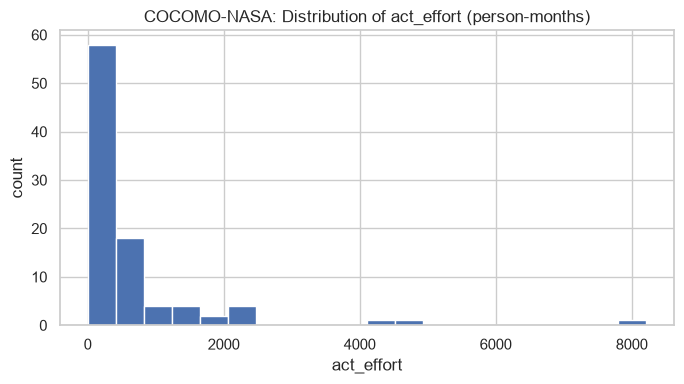

In [6]:
plt.figure(figsize=(7, 4))
plt.hist(cocomo["act_effort"], bins=20, color="#4C72B0", edgecolor="white")
plt.title("COCOMO-NASA: Distribution of act_effort (person-months)")
plt.xlabel("act_effort")
plt.ylabel("count")
plt.tight_layout()
plt.show()


### 1.6 Key numeric feature distributions

The only truly numeric (non-ordinal, non-ID) columns available are `equivphyskloc` (project size), `year`, and `center`.

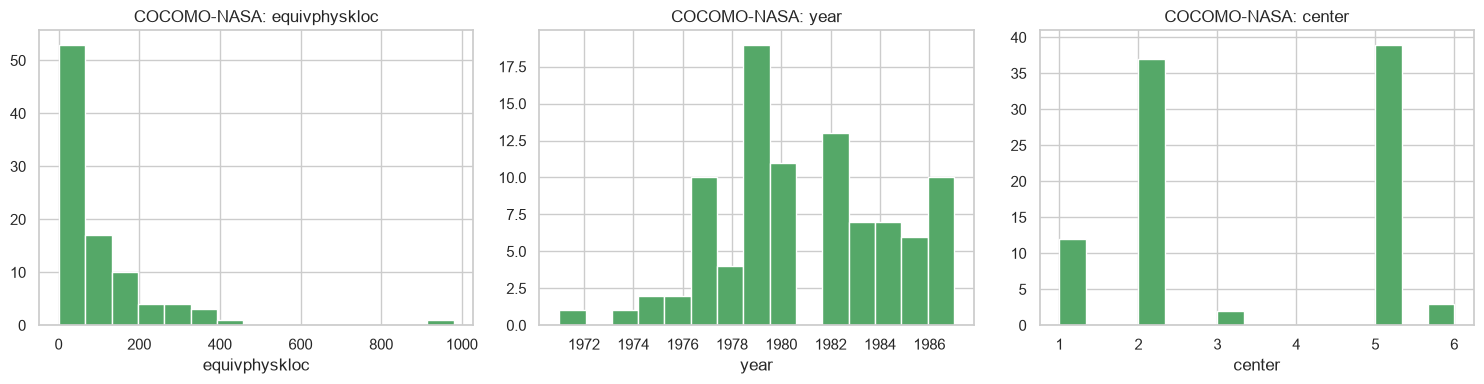

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["equivphyskloc", "year", "center"]):
    ax.hist(cocomo[col], bins=15, color="#55A868", edgecolor="white")
    ax.set_title(f"COCOMO-NASA: {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()


### 1.7 Outlier check — boxplot of target

/var/folders/c1/5bxpyhqn50zcsk6w154rhl7h0000gn/T/ipykernel_7369/3291927722.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(cocomo["act_effort"], vert=False)


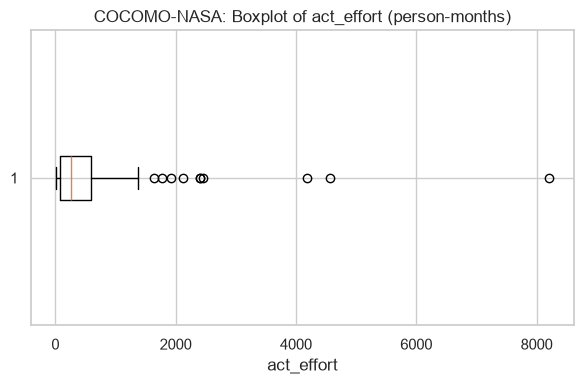

In [8]:
plt.figure(figsize=(6, 4))
plt.boxplot(cocomo["act_effort"], vert=False)
plt.title("COCOMO-NASA: Boxplot of act_effort (person-months)")
plt.xlabel("act_effort")
plt.tight_layout()
plt.show()


### 1.8 Correlation of numeric features with the target

Only columns with numeric dtype are included — the ordinal effort-driver ratings (`rely`, `cplx`, etc.) are stored as text categories, not numbers, so they are excluded here (this is exactly the kind of thing Step 4 preprocessing needs to handle, e.g. via ordinal encoding).

In [9]:
numeric_cocomo = cocomo.select_dtypes(include=[np.number])
corr_cocomo = numeric_cocomo.corr(numeric_only=True)["act_effort"].drop("act_effort").sort_values(ascending=False)
print("Correlation with act_effort, highest to lowest:")
corr_cocomo


Correlation with act_effort, highest to lowest:


equivphyskloc    0.594941
center           0.421006
recordnumber     0.394758
year            -0.354663
Name: act_effort, dtype: float64

---
## 2. Desharnais dataset

Source: `data/raw/desharnais.csv` — 81 software projects from a Canadian software house. Known
from the source documentation to have 4 incomplete projects (38, 44, 66, 75) with missing
`TeamExp`/`ManagerExp` values encoded as a literal `?` in the raw CSV.


In [10]:
desharnais = pd.read_csv("../data/raw/desharnais.csv")
desharnais.shape


(81, 12)

### 2.1 Structure — `.info()`

Read with default settings first, so dtypes reflect exactly what's in the raw file (note `TeamExp`/`ManagerExp` come in as object/string dtype because of the `?` placeholders).

In [11]:
desharnais.info()


<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Project         81 non-null     int64
 1   TeamExp         81 non-null     str  
 2   ManagerExp      81 non-null     str  
 3   YearEnd         81 non-null     int64
 4   Length          81 non-null     int64
 5   Effort          81 non-null     int64
 6   Transactions    81 non-null     int64
 7   Entities        81 non-null     int64
 8   PointsAdjust    81 non-null     int64
 9   Envergure       81 non-null     int64
 10  PointsNonAjust  81 non-null     int64
 11  Language        81 non-null     int64
dtypes: int64(10), str(2)
memory usage: 7.9 KB


### 2.2 Summary statistics — `.describe()`

In [12]:
desharnais.describe(include="all")


,Project,TeamExp,ManagerExp,YearEnd,Length,Effort,Transactions,Entities,PointsAdjust,Envergure,PointsNonAjust,Language
count,81.000000,81,81,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
unique,NaN,6,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,41.000000,NaN,NaN,85.790123,11.716049,5046.308642,179.901235,122.333333,302.234568,27.629630,287.049383,1.555556
std,23.526581,NaN,NaN,1.147999,7.399721,4418.767228,143.314916,84.882124,179.676812,10.591795,185.108137,0.707107
min,1.000000,NaN,NaN,83.000000,1.000000,546.000000,9.000000,7.000000,73.000000,5.000000,62.000000,1.000000
25%,21.000000,NaN,NaN,85.000000,6.000000,2352.000000,88.000000,57.000000,176.000000,20.000000,152.000000,1.000000
50%,41.000000,NaN,NaN,86.000000,10.000000,3647.000000,139.000000,99.000000,260.000000,28.000000,253.000000,1.000000
75%,61.000000,NaN,NaN,87.000000,14.000000,5922.000000,223.000000,169.000000,382.000000,35.000000,350.000000,2.000000


### 2.3 Missing values per column

Standard NaN check first, then literal `?` placeholder check — this dataset is expected to have `?` values.

In [13]:
nan_counts = desharnais.isnull().sum()
q_counts = (desharnais.astype(str) == "?").sum()

missing_summary = pd.DataFrame({"nan_count": nan_counts, "literal_?_count": q_counts})
missing_summary = missing_summary[(missing_summary["nan_count"] > 0) | (missing_summary["literal_?_count"] > 0)]
print("Columns with any missing/placeholder values:")
missing_summary


Columns with any missing/placeholder values:


,nan_count,literal_?_count
TeamExp,0,2
ManagerExp,0,3


In [14]:
rows_with_q = desharnais[(desharnais.astype(str) == "?").any(axis=1)]
print(f"{len(rows_with_q)} rows contain a literal '?':")
rows_with_q


4 rows contain a literal '?':


,Project,TeamExp,ManagerExp,YearEnd,Length,Effort,Transactions,Entities,PointsAdjust,Envergure,PointsNonAjust,Language
37,38,?,?,87,8,5922,260,144,404,24,360,1
43,44,?,4,86,39,19894,284,230,514,50,591,1
65,66,2,?,87,10,6783,224,110,334,28,311,2
74,75,0,?,84,22,3941,139,143,282,22,245,2


### 2.4 Target variable

The target is **`Effort`** — actual development effort in **person-hours**. `Project` is just a row
ID, not a feature.

### 2.5 Target distribution — histogram

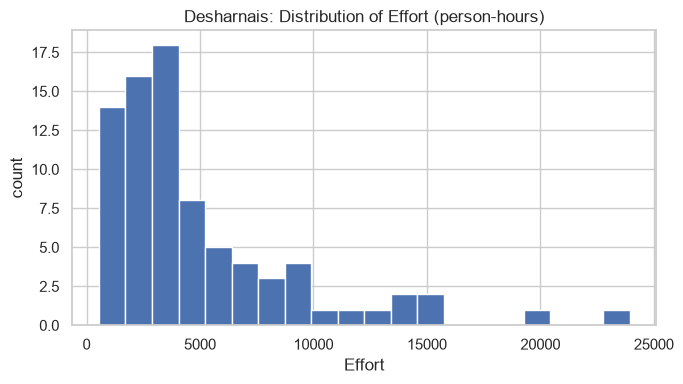

In [15]:
plt.figure(figsize=(7, 4))
plt.hist(desharnais["Effort"], bins=20, color="#4C72B0", edgecolor="white")
plt.title("Desharnais: Distribution of Effort (person-hours)")
plt.xlabel("Effort")
plt.ylabel("count")
plt.tight_layout()
plt.show()


### 2.6 Key numeric feature distributions

Using `pd.to_numeric(..., errors="coerce")` purely for *plotting purposes* here so the `?` placeholders don't crash the histogram — this does not alter the underlying CSV or `desharnais` DataFrame, it's a display-only conversion local to this cell.

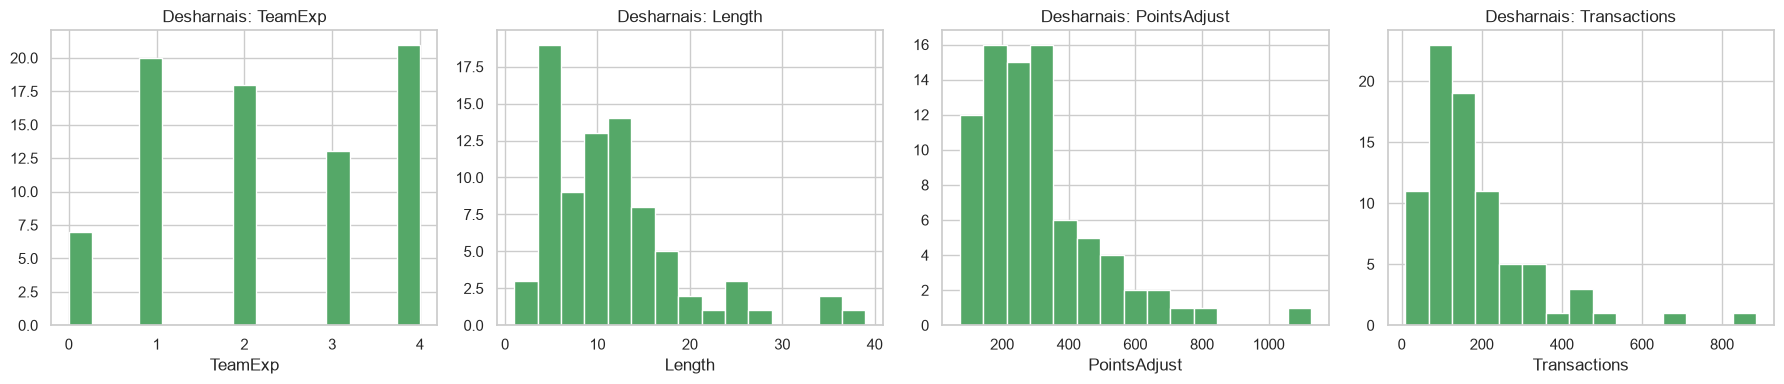

In [16]:
features = ["TeamExp", "Length", "PointsAdjust", "Transactions"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, features):
    values = pd.to_numeric(desharnais[col], errors="coerce").dropna()
    ax.hist(values, bins=15, color="#55A868", edgecolor="white")
    ax.set_title(f"Desharnais: {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()


### 2.7 Outlier check — boxplot of target

/var/folders/c1/5bxpyhqn50zcsk6w154rhl7h0000gn/T/ipykernel_7369/1980343304.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(desharnais["Effort"], vert=False)


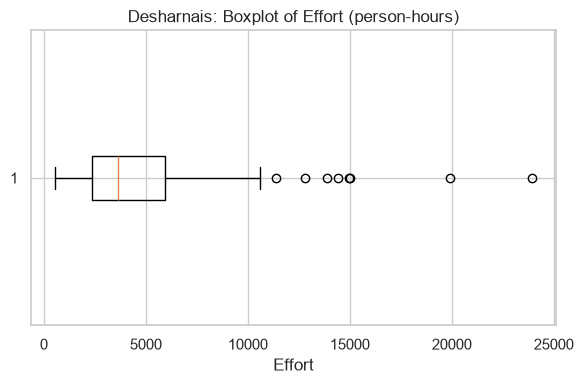

In [17]:
plt.figure(figsize=(6, 4))
plt.boxplot(desharnais["Effort"], vert=False)
plt.title("Desharnais: Boxplot of Effort (person-hours)")
plt.xlabel("Effort")
plt.tight_layout()
plt.show()


### 2.8 Correlation of numeric features with the target

`Language` is numeric dtype (1/2/3) but is actually a nominal category code, not a true quantity — its correlation value is included but should be read with that caveat in mind ahead of Step 4.

In [18]:
numeric_desharnais = desharnais.select_dtypes(include=[np.number])
corr_desharnais = numeric_desharnais.corr(numeric_only=True)["Effort"].drop("Effort").sort_values(ascending=False)
print("Correlation with Effort, highest to lowest:")
corr_desharnais


Correlation with Effort, highest to lowest:


PointsNonAjust    0.729743
PointsAdjust      0.695956
Length            0.689834
Transactions      0.570278
Entities          0.510328
Envergure         0.463865
Project           0.126153
YearEnd          -0.007409
Language         -0.261942
Name: Effort, dtype: float64

---
## 3. Summary — before moving to Step 4 (preprocessing)

**Columns: COCOMO-NASA vs. Desharnais — they do NOT share a schema**

- COCOMO-NASA (24 columns): `recordnumber`, `projectname`, `cat2`, `forg`, `center`, `year`, `mode`,
  15 ordinal effort-driver ratings (`rely`, `data`, `cplx`, `time`, `stor`, `virt`, `turn`, `acap`,
  `aexp`, `pcap`, `vexp`, `lexp`, `modp`, `tool`, `sced`), `equivphyskloc` (size), and the target
  `act_effort` (person-months).
- Desharnais (12 columns): `Project`, `TeamExp`, `ManagerExp`, `YearEnd`, `Length`, `Transactions`,
  `Entities`, `PointsAdjust`, `Envergure`, `PointsNonAjust`, `Language`, and the target `Effort`
  (person-hours).
- **No columns are shared between the two datasets** — different domains, different units, different
  effort measures (person-months vs. person-hours). They must be preprocessed and modeled
  **separately**, not concatenated/merged.

**Missing values**

- COCOMO-NASA: no missing values found (no NaNs, no literal `?` placeholders) across all 24 columns.
- Desharnais: 5 literal `?` placeholders masquerading as strings, **not** caught by `.isnull()`:
  `TeamExp` (2 missing) and `ManagerExp` (3 missing), across the 4 known-incomplete projects
  (`Project` 38, 44, 66, 75). These will need explicit handling (e.g. convert to NaN + impute) in
  Step 4 — a plain `.isnull().sum()` alone would have silently missed this.

**Correlation with target (numeric features only)**

- COCOMO-NASA: only a handful of columns are numeric dtype to begin with (`equivphyskloc`, `year`,
  `center`, plus the ID `recordnumber`) since most predictors are ordinal-categorical text
  (`vl`/`l`/`n`/`h`/`vh`/`xh`). Of those, **`equivphyskloc` (project size in KLOC, r ≈ 0.59)** shows
  the strongest correlation with `act_effort`, which matches domain expectations (bigger projects
  cost more effort). Note `recordnumber` (r ≈ 0.39) is just a row ID, not a real feature — its
  non-trivial correlation is spurious (likely an artifact of rows being roughly ordered by year) and
  should be excluded as a predictor in Step 4, not treated as a genuine signal. The 15 ordinal rating
  columns are currently invisible to a numeric correlation check — they'll need ordinal/one-hot
  encoding in Step 4 before their relationship with effort can be assessed quantitatively.
- Desharnais: **`PointsNonAjust` (r ≈ 0.73), `PointsAdjust` (r ≈ 0.70), and `Length` (r ≈ 0.69)**
  show the strongest positive correlation with `Effort`, with `Transactions` and `Entities` close
  behind — all function-point/size-related measures, consistent with "bigger systems take more
  effort." `Language` shows a negative correlation (r ≈ -0.26) despite being a nominal category code
  (1/2/3), which is a reminder to treat it as categorical, not ordinal, in Step 4. `TeamExp`/
  `ManagerExp` correlations should be treated cautiously since they currently include only the 77
  complete rows (the 4 rows with `?` are excluded from a raw `.corr()` call automatically as
  non-numeric).

**Outliers / data-quality issues to flag before Step 4**

- Both target distributions (`act_effort`, `Effort`) are strongly **right-skewed** with a long tail
  of a few very large/expensive projects — visible in both the histograms and the boxplots, which
  show multiple points beyond the upper whisker. A log transform of the target is worth considering
  during preprocessing/modeling.
- Desharnais has the 4 rows with literal `?` missing-value placeholders noted above — these must be
  converted to real NaNs (they are currently just strings) and either imputed or dropped explicitly;
  right now they'd be silently dropped from any numeric operation instead of being handled
  deliberately.
- COCOMO-NASA's effort-driver columns are ordinal-scale categories, not free-text categoricals —
  Step 4 should preserve their natural ordering (e.g. `vl < l < n < h < vh < xh`) via ordinal
  encoding rather than one-hot encoding, to avoid losing that structure.
- No duplicate rows or obviously corrupted values were observed in either dataset during this pass.
